# Chandra Imaging of SNR G299.2-2.9

In this project you are going to image the Super Nova remnant G299.2-2.9 from a chandra observation. Detailed modeling is quite complex, so we will perform a simplified version here.

## Loading data and response

In order to model Chandra and its instrument response, we require details of the instrument configuration at the time the data was collected. 
Typically, we obtain this information from Ciao (https://cxc.cfa.harvard.edu/ciao/), a software package for Chandra data analysis. This step has already been completed here, so you don't need to worry about the details and can start imaging right away. We load the exposure and the point spread function (PSF) from a file after importing the necessary Python packages for the script.

In [111]:
# Imports
import jax
from jax import random

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import nifty.re as jft
from jax.tree_util import Partial
from jax.scipy.stats import poisson
%matplotlib inline 



# Set jax to float64
jax.config.update("jax_enable_x64", True)

# RNG configuration
seed = 42
key = random.PRNGKey(seed)

# loading files
data = jnp.load("x-ray-files/chandra_11101_data.npy")
exposure = jnp.load("x-ray-files/chandra_11101_exposure.npy")
psf = jnp.load("x-ray-files/chandra_11101_psf.npy")
pixel_size = 1 # 

# First steps
Before we begin with the imaging process, we will familiarize ourselves with the data. Take a look at the data, the exposure and the point spread function. Do you remember from the presentation:

- What is the data? What was measured?
- What is the exposure?
- What is a point spread function?

Plotting the data will give you a better understanding of the individual parts.

- Also plot the exposure corrected data to get a feeling for the flux in the signal domain. (data/exposure)

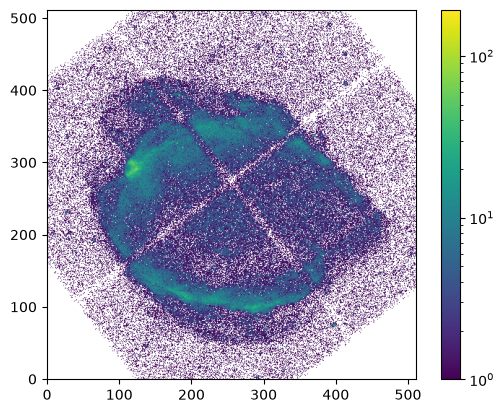

In [112]:
plt.imshow(data, origin="lower", norm="log")
plt.colorbar()

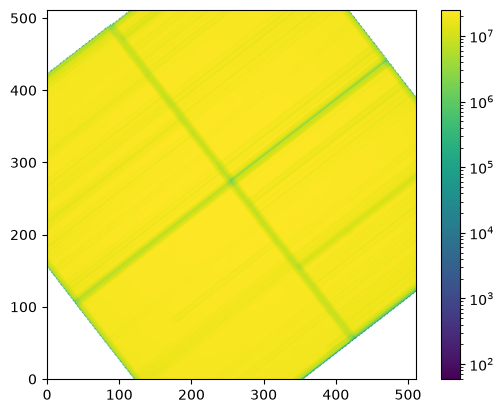

In [113]:
plt.imshow(exposure, origin="lower", norm="log")
plt.colorbar()

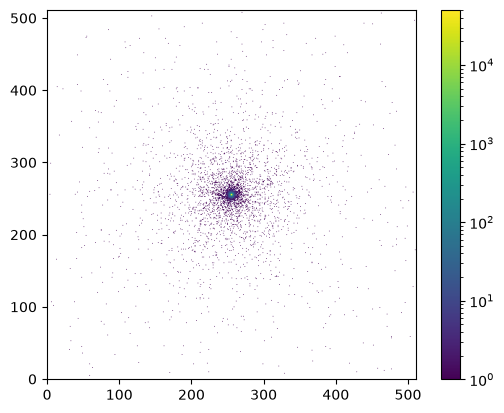

In [114]:
plt.imshow(psf, origin="lower", norm="log")
plt.colorbar()

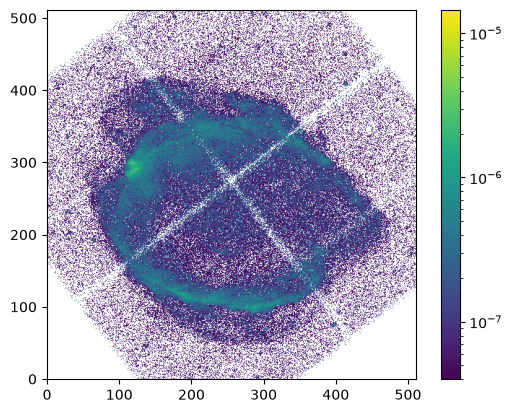

In [115]:
exposure_corrected = data / exposure

plt.imshow(exposure_corrected, origin="lower", norm = "log")
plt.colorbar()

# Model
First we want to model the sky brightness with the correlated field model. Therefore you will need some more information about the data:
- Field of view (FOV) is 960 arcsec 
- Spatial pixel = 512x512
- Energy bins = 1 with energy range from 0.5-7 keV
  
The information about the energy is not needed for the model we use.
## To Do:
- build a lognormal model from the correlated field model.
- draw prior latent variables
- plot the prior sample

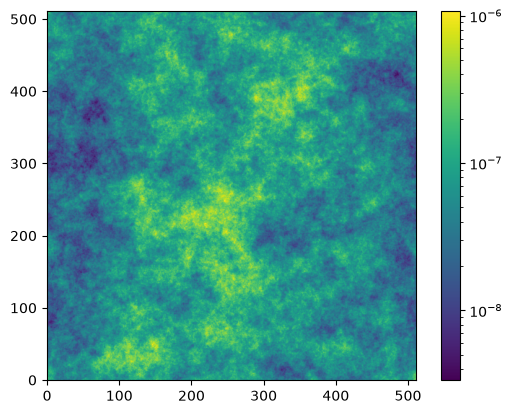

In [116]:
grid = (512,512)
fov = 960
distances = tuple(fov / g for g in grid)


cf_offset_dict = {
    "offset_mean": -17,
    "offset_std": (1., 0.1),
}
cf_ps_dict = {
    "shape": grid,
    "distances": distances,
    "non_parametric_kind": "power",
    "fluctuations": (1., 0.5),
    "loglogavgslope": (-2.7, 0.5 ),
    "flexibility": None,
    "asperity": None,
}

# CorrelatedFieldMaker -> log_s
cf_maker = jft.CorrelatedFieldMaker("signal_")
cf_maker.set_amplitude_total_offset(**cf_offset_dict)
cf_maker.add_fluctuations(**cf_ps_dict)
log_s = cf_maker.finalize()


# draw a latent xi ~ N(0,1), evaluate, exponentiate -> s; shared colour scale
s = jnp.exp(log_s(log_s.init(key)))

# plot s -- axis 0 is x and axis 1 is y, so transpose for imshow
plt.imshow(s, origin="lower", norm = "log")
plt.colorbar()



# Optional: Point Source Model
To model point sources, you can use the [Inverse Gamma Prior](https://en.wikipedia.org/wiki/Inverse-gamma_distribution).
This distribution has to parameters, alpha and scale.
Play around the parameters, have a look at the prior samples.

```python
    points = jft.InvGammaPrior(alpha, scale, shape=grid, name="points")
```

## optional To Do
- build point source model
- draw latent variables
- visualize the point source sample

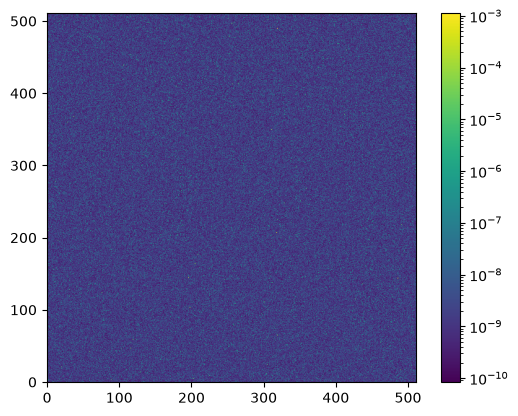

In [117]:
alpha = 1.005
scale = 1e-9

points = jft.InvGammaPrior(alpha, scale, shape=grid, name="points")
points_sample = points(points.init(key))

plt.imshow(points_sample, norm = "log", origin="lower")
plt.colorbar()


# Build a sky model from your components
For the inference you need to wrap you functions into a model.
```python
sky = jft.Model(
    call=lambda x: model1(x)+ model2(x), domain=model1.domain | model2.domain, white_init=True
)
```
Have a look at you full sky model prior sample and plot it.

In [118]:
sky = jft.Model(
    call=lambda x: jnp.exp(log_s(x)) + points(x), domain = log_s.domain | points.domain,
    white_init=True
)

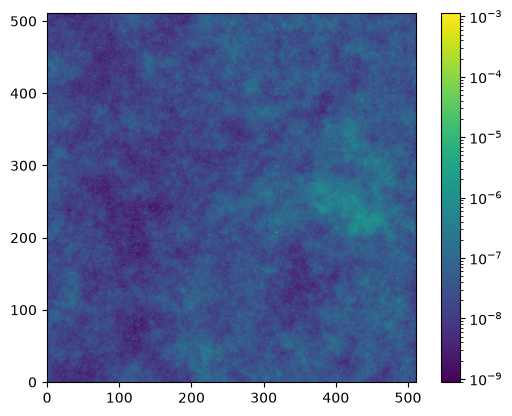

In [119]:
sky_sample = sky(sky.init(key))
plt.imshow(sky_sample, origin="lower", norm="log")
plt.colorbar()

## Response

The instrument response R for Chandra is basically:

$$R = M \circ E \circ P$$

$M$ is the mask, $E$ the exposure, $P$ the PSF.

In [ ]:
def chandra_response(exposure, psf):
    """Convenience function to retrieve the instrument response 
    for this observation

    Parameters:
    -----------
    exposure: np.array
    psf: np.array

    Returns:
    -------
    signal_response: callable
    """
    # prep psf for convolution (normalize and shift)
    integral = psf.sum()*pixel_size
    psf = psf / integral
    psf = jnp.fft.fftshift(psf)
    
    def convolve(signal):
        """FFT convolution code"""
        psf_k = jnp.fft.fftn(psf)
        signal_k = jnp.fft.fftn(signal)
        conv = jnp.fft.ifftn(signal_k*psf_k)
        return conv.real

    def expose(signal):
        exposed = exposure*signal
        return exposed

    def mask(signal):
        """Mask all unexposed parts of the signal."""
        flag = exposure!=0
        return signal[flag]

    # Function to backproject the data to image domain
    mask_adj_temp = jax.linear_transpose(mask, jnp.ones(grid))
    mask_adj = lambda x: mask_adj_temp(x)[0]
    # All parts of the response in a dict
  
    # Full response
    signal_response = lambda x: mask(expose(convolve(x)))
    dct = {"conv": convolve,
           "exposure": expose,
           "mask": mask,
           "mask_adj": mask_adj,
          "signal_response": signal_response,}
    
    return dct

In [121]:
instrument_dct = chandra_response(np.array(exposure), psf)
R = instrument_dct["signal_response"]
M_adj = instrument_dct["mask_adj"]
M = instrument_dct["mask"]

# Model of signal response
- wrap you signal response in a Model
- look at you prior sky and compare it to the data (you need to backproject the R(s) to the image domain. `M_adj(R(s))`

In [122]:
signal_model = jft.Model(call = lambda x: R(sky(x)), domain= sky.domain)


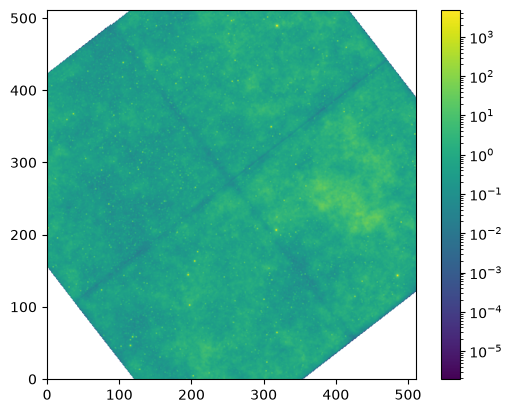

In [123]:
sample = M_adj(R(sky_sample))
plt.imshow(sample, origin="lower", norm= "log")
plt.colorbar()

# Likelihood
For this experiment you'll need a Poissonian likelihood `jft.Poissonian`. The Poissonian Hamiltonian is
$$\log\mathcal{P}(d|s)=  \sum \lambda - d\log\lambda$$

To do:
- mask the data, where the signal response is 0 (exposure is 0). (you can use the mask)
- build likelihood with the data and the signal response

In [124]:
d = M(data)


In [125]:
#lh = jft.Model(likelihood_call, domain=sky.domain)

lh = jft.Poissonian(d).amend(signal_model)

/home/genya/.venv/lib/python3.14/site-packages/nifty/re/model.py:190: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


# Inference

- Use optimize_kl to do the inference.
- you can use to plotting callback, to look at the results

In [126]:
def _imshow(figure, field, ax, title, vmin=1e-8, vmax=None, norm=None, cmap="viridis"):
    im0 = ax.imshow(
        field,
        origin="lower",
        extent=[0, fov, 0, fov],
        vmin=vmin,
        cmap=cmap,
        vmax=vmax,
        norm=norm,
    )
    figure.colorbar(im0, ax=ax)
    ax.set_xlabel(r"x $\left( arcsec \right)$")
    ax.set_ylabel(r"y $\left( arcsec \right)$")
    ax.set_title(title)
    
def plotting_callback(samples, opt_state):
    m_data = M(data)
    def nwr(sky):
        sr = R(sky)
        nwr=(m_data-sr)/jnp.sqrt(sr)
        nwr_image = M_adj(nwr)
        return nwr_image
        
    sky_mean, sky_std = jft.mean_and_std(tuple(sky(s) for s in samples))
    nwr_mean = jft.mean(tuple(nwr(sky(s)) for s in samples))
    
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 13))
    axs = axs.flatten()
    
    _imshow(fig, sky_mean, axs[0], "Sky brightness mean",norm="log", cmap="viridis",)
    _imshow(fig, sky_std, axs[1], "Sky brightness std", norm="log",cmap="viridis")
    _imshow(fig, data/exposure, axs[2], "Exposure corrected data", norm="log", cmap="viridis")
    _imshow(fig, nwr_mean, axs[3], "noise weighted residuals", vmin=-5, vmax=5,cmap="bwr")

    axs[1].yaxis.set_visible(False)
    axs[3].yaxis.set_visible(False)

    fig.tight_layout()
    file_name = f"x_ray_imaging_{opt_state.nit}.png"
    plt.savefig(file_name)
    plt.close()

In [127]:
key, k_init, k_opt = random.split(key, 3)

samples,  = jft.optimize_kl(
    likelihood=lh,
    position_or_samples=jft.Vector(lh.init(k_init)) * 0.0,
    key=k_opt,
    n_total_iterations=4,
    n_samples=8,
    sample_mode="nonlinear_resample",
    callback= plotting_callback,
    draw_linear_kwargs=dict(
        cg_name=None,
        cg_kwargs=dict(miniter=100),
    ),
    nonlinearly_update_kwargs=dict(
        minimize_kwargs=dict(
            name=None,
            maxiter=5,
            cg_kwargs=dict(name=None, maxiter=10),
        )
    ),
    kl_kwargs=dict(
        minimize_kwargs=dict(
            name=None,
            cg_kwargs=dict(name=None),
        )
    ),
)


<frozen genericpath>:39: RuntimeWarning: bool is used as a file descriptor
OPTIMIZE_KL: Starting 0001
OPTIMIZE_KL: Iteration 0001 E:+2.0443e+05
OPTIMIZE_KL: #(Nonlinear sampling steps) (2, 3, 3, 2, 2, 4, 2, 3, 4, 2, 2, 3, 3, 3, 3, 3)
OPTIMIZE_KL: #(KL minimization steps) 30
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     1.6±    0.41, avg:   -0.058±    0.15, #dof: 232321'

OPTIMIZE_KL: Prior residual(s):
points                  :: 'reduced Chi²:     1.0±  0.0044, avg:   -0.024±  0.0029, #dof: 262144'
signal_fluctuations     :: 'reduced Chi²:     1.5±     1.6, avg:    +0.88±    0.83, #dof:      1'
signal_loglogavgslope   :: 'reduced Chi²:     5.4±     3.8, avg:     -2.2±    0.82, #dof:      1'
signal_xi               :: 'reduced Chi²:    0.98±  0.0033, avg: +2.4e-05±  0.0021, #dof: 262144'
signal_zeromode         :: 'reduced Chi²:     4.3±     4.3, avg:     -1.7±     1.2, #dof:      1'


OPTIMIZE_KL: Starting 0002
OPTIMIZE_KL: Iteration 0002 E:+1.6167e+05
OPTIMIZE_KL: #(Nonlinea

ValueError: too many values to unpack (expected 1, got 2)

# Plotting
In the case that you added a point source component, you can visualize the points and the diffuse seperatly.